```
## GraphSAGE_Data002_NodeManufacturing_v1.ipynb

Inputs
------
Superfunds:
- /content/DATA001_superfund_feature_matrix_v1.csv
- /content/DATA001_superfund_node_id_map_v1.csv
Counties:
- /content/DATA002_county_feature_matrix_v1.csv
- /content/DATA002_county_node_id_map_v1.csv

Output:
- superfund/county node set
- superfund/county node edge index
- Heterograph Data Object
```

```
# ───────────────────────────────────────────────────────────────────────
# CODE CELL 1.0: ENVIRONMENT AND RUNTIME CONTROL
# ───────────────────────────────────────────────────────────────────────

Note: This notebook is being developed with Python in a Colab notebook
using an L4 or A100 hardware accelerator. There are runtime-specific   
dependencies that must be aligned. Cell 1 should be run prior to   
starting work in each new runtime. After Cell 1 completes, the runtime  
must be restarted. Cell 1 may then be commented out to avoid   
reinstalling the dependencies after subsequent runtime restarts.
```

In [ ]:
# !pip uninstall -y torch torchvision torchaudio torch-scatter torch-sparse torch-geometric
# !pip install torch==2.0.0+cu118 torchvision==0.15.1+cu118 torchaudio==2.0.1+cu118 -f https://download.pytorch.org/whl/torch_stable.html
# !pip install torch-scatter torch-sparse torch-geometric -f https://data.pyg.org/whl/torch-2.0.0+cu118.html
# !pip install numpy==1.24.4
# !pip install Optuna

```
# ───────────────────────────────────────────────────────────────────────
# CODE CELL 2.0: IMPORT STATEMENTS
# ───────────────────────────────────────────────────────────────────────
```

In [ ]:
# Torch and torch utilities are for construction of HeteroGRAPH object
# ───────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch_geometric
from torch_geometric.data import HeteroData
from torch.optim import Adam
from torch_geometric.nn import SAGEConv, HeteroConv
import numpy as np


# Sklearn encoder, training and evaluation tools
# ───────────────────────────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import optuna

# Data handling libraries
# ───────────────────────────────────────────────────────────────────────
from shapely.geometry import Point # For reading geometry in super_gdf
import geopandas as gpd            # For loading super_gdf
import pandas as pd

# Utilities
# ───────────────────────────────────────────────────────────────────────
from google.colab import files
import random
import inspect
import math
import time
import re

# Utilities
# ───────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import tabulate
from tabulate import tabulate
import collections
from collections import Counter

# Set random state for everything, everywhere, all at once.
# ───────────────────────────────────────────────────────────────────────
def jenny_setter(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

jenny = 8675309
jenny_setter(seed=jenny)

# Check runtime dependency control. Confirm correct PyTorch, CUDA, numpy.
# ───────────────────────────────────────────────────────────────────────
rows = [
        ["Torch", "Torch 2.0.0", torch.__version__],
        ["CUDA_version", "11.8", torch.version.cuda],
        ["NumPy", "NumPy 1.24.4", np.__version__]
       ]
print(tabulate(rows, headers=["Library", "Expected Version", "Current Version"], tablefmt="grid"))

+--------------+--------------------+-------------------+
| Library      | Expected Version   | Current Version   |
+==============+====================+===================+
| Torch        | Torch 2.0.0        | 2.0.0+cu118       |
+--------------+--------------------+-------------------+
| CUDA_version | 11.8               | 11.8              |
+--------------+--------------------+-------------------+
| NumPy        | NumPy 1.24.4       | 1.24.4            |
+--------------+--------------------+-------------------+


In [ ]:
superfund_feature_matrix = pd.read_csv('/content/DATA001_superfund_feature_matrix_v1.csv', low_memory=False)
superfund_node_id_map = pd.read_csv('/content/DATA001_superfund_node_id_map_v1.csv', low_memory=False)
county_feature_matrix = pd.read_csv('/content/DATA002_county_feature_matrix_v1.csv', low_memory=False)
county_node_id_map = pd.read_csv('/content/DATA002_county_node_id_map_v1.csv', low_memory=False)

# >>> Enforce formats (strings, padded to n digits) for id columns <<<
# >>> ------------------------------------------------------------ <<<
superfund_node_id_map['site_id'] = superfund_node_id_map['site_id'].astype(str).str.zfill(7)
superfund_node_id_map['fips'] = superfund_node_id_map['fips'].astype(str).str.zfill(5)
county_node_id_map['fips'] = county_node_id_map['fips'].astype(str).str.zfill(5)

# >>> Cast everything in feature matrices to float32; mixed dtypes <<<
# >>> trigger implicit casting when used in PyTorch Geo operations <<<
# >>> ------------------------------------------------------------ <<<
superfund_feature_matrix = superfund_feature_matrix.astype(np.float32)
county_feature_matrix = county_feature_matrix.astype(np.float32)

```
# ───────────────────────────────────────────────────────────────────────
# CODE CELL 3.0: DATA - IMPORT VERIFICATION
# ───────────────────────────────────────────────────────────────────────
```


In [ ]:
display(superfund_feature_matrix.info())
print('-------------------------------')
print('__ HEAD __')
display(superfund_feature_matrix.head())
print('-------------------------------')
print('__ SHAPE __')
display(superfund_feature_matrix.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1606 entries, 0 to 1605
Columns: 739 entries, lat to npl_proposed
dtypes: float32(739)
memory usage: 4.5 MB


None

-------------------------------
__ HEAD __


,lat,lon,fed_facility,native_land,hazard_rank_score,final_list_days,proposed_days,proposal_gulf,is_finalized,is_deleted,...,99-35-4,99-65-0,99-87-6,99-99-0,993-13-5,UNASSIGNED,cas_sum,npl_current,npl_deleted,npl_proposed
0,41.940559,-71.966942,0.0,0.0,33.709999,12733.0,13340.0,607.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,35.0,1.0,0.0,0.0
1,41.481110,-72.681389,0.0,0.0,33.939999,12873.0,13340.0,467.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,43.0,1.0,0.0,0.0
2,41.708332,-71.829170,0.0,0.0,41.060001,13678.0,14085.0,407.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,1.0,0.0
3,41.619598,-72.877998,0.0,0.0,44.930000,15091.0,15343.0,252.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,94.0,1.0,0.0,0.0
4,41.669449,-71.964165,0.0,0.0,36.720001,15091.0,15343.0,252.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,66.0,1.0,0.0,0.0


-------------------------------
__ SHAPE __


(1606, 739)

In [ ]:
display(superfund_node_id_map.info())
print('-------------------------------')
print('__ HEAD __')
display(superfund_node_id_map.head())
print('-------------------------------')
print('__ SHAPE __')
display(superfund_node_id_map.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1606 entries, 0 to 1605
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   row_index  1606 non-null   int64 
 1   site_id    1606 non-null   object
 2   fips       1606 non-null   object
dtypes: int64(1), object(2)
memory usage: 37.8+ KB


None

-------------------------------
__ HEAD __


,row_index,site_id,fips
0,0,0100041,09150
1,1,0100108,09130
2,2,0100121,09150
3,3,0100124,09110
4,4,0100125,09150


-------------------------------
__ SHAPE __


(1606, 3)

In [ ]:
display(county_feature_matrix.info())
print('-------------------------------')
print('__ HEAD/TAIL __')
display(county_feature_matrix.head())
display(county_feature_matrix.tail())
print('-------------------------------')
print('__ SHAPE __')
display(county_feature_matrix.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cancer_rate       2930 non-null   float32
 1   avg_annual_count  2930 non-null   float32
 2   five_year_trend   2930 non-null   float32
 3   rural_rural       2930 non-null   float32
 4   rural_urban       2930 non-null   float32
 5   trend_            2930 non-null   float32
 6   trend_falling     2930 non-null   float32
 7   trend_rising      2930 non-null   float32
 8   trend_stable      2930 non-null   float32
dtypes: float32(9)
memory usage: 103.1 KB


None

-------------------------------
__ HEAD/TAIL __


,cancer_rate,avg_annual_count,five_year_trend,rural_rural,rural_urban,trend_,trend_falling,trend_rising,trend_stable
0,693.500000,37.0,2.2,1.0,0.0,0.0,0.0,0.0,1.0
1,679.500000,436.0,-0.3,1.0,0.0,0.0,0.0,0.0,1.0
2,655.000000,55.0,1.7,1.0,0.0,0.0,0.0,0.0,1.0
3,653.099976,21.0,0.7,1.0,0.0,0.0,0.0,0.0,1.0
4,634.500000,28.0,1.3,1.0,0.0,0.0,0.0,0.0,1.0


,cancer_rate,avg_annual_count,five_year_trend,rural_rural,rural_urban,trend_,trend_falling,trend_rising,trend_stable
2925,219.100006,7.0,-999.0,1.0,0.0,1.0,0.0,0.0,0.0
2926,219.000000,6.0,-2.1,0.0,1.0,0.0,0.0,0.0,1.0
2927,208.000000,10.0,-2.5,1.0,0.0,0.0,0.0,0.0,1.0
2928,207.399994,4.0,-1.6,1.0,0.0,0.0,0.0,0.0,1.0
2929,182.300003,3.0,-5.2,1.0,0.0,0.0,0.0,0.0,1.0


-------------------------------
__ SHAPE __


(2930, 9)

In [ ]:
display(county_node_id_map.info())
print('-------------------------------')
print('__ HEAD/TAIL __')
display(county_node_id_map.head())
display(county_node_id_map.tail())
print('-------------------------------')
print('__ SHAPE __')
display(county_node_id_map.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   row_index  2930 non-null   int64 
 1   fips       2930 non-null   object
dtypes: int64(1), object(1)
memory usage: 45.9+ KB


None

-------------------------------
__ HEAD/TAIL __


,row_index,fips
0,0,27155
1,1,48373
2,2,51640
3,3,31077
4,4,46041


,row_index,fips
2925,2925,02013
2926,2926,38065
2927,2927,48243
2928,2928,08079
2929,2929,08053


-------------------------------
__ SHAPE __


(2930, 2)

In [ ]:
# >>> Check that fips match between superfund and county id_maps.          <<<
# >>> -------------------------------------------------------------------- <<<
valid_fips = set(county_node_id_map['fips'])
superfund_fips = set(superfund_node_id_map['fips'])
print("Edges possible:", len(superfund_fips & valid_fips), "/", len(superfund_fips))

# >>> Check that fips are all digit-only and appropriately 5-padded.       <<<
# >>> -------------------------------------------------------------------- <<<
valid_fips = county_node_id_map['fips'].apply(lambda x: isinstance(x, str) and len(x) == 5 and x.isdigit())
print("Valid FIPS count:", valid_fips.sum(), "/", len(county_node_id_map))

Edges possible: 677 / 738
Valid FIPS count: 2930 / 2930


```
# ───────────────────────────────────────────────────────────────────────
# CODE CELL 4.0: EDGE CONSTRUCTION
# ───────────────────────────────────────────────────────────────────────
```

In [ ]:
# ────────────────────────────────────────────────────────────────────────── <<<
# >>> CODE CELL 4.1: EDGE CONSTRUCTION / INSTANTIATE DATA OBJECT             <<<
# ────────────────────────────────────────────────────────────────────────── <<<

# >>> Create base edge index <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<
edge_df = superfund_node_id_map.merge(county_node_id_map, on='fips',
                                      suffixes=('_superfund', '_county')).copy(deep=True)
edge_array = np.stack([
    edge_df['row_index_superfund'].values,
    edge_df['row_index_county'].values
], axis=0)
edge_index = torch.from_numpy(edge_array).long()
# >>> ────────────────────────────────────────────────────────────────────── <<<

# >>> VERIFICATION OF SHAPE                                                  <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<
print("Edge index shape:", edge_index.shape)
# >>> ────────────────────────────────────────────────────────────────────── <<<

# >>> TURN FEATURE MATRICES TO TENSORS                                       <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<
superfund_x = torch.tensor(superfund_feature_matrix.values, dtype=torch.float32)
county_x = torch.tensor(county_feature_matrix.values, dtype=torch.float32)

# >>> INSTANTIATE HETERODATA OBJECT AND ADD FEATURES                         <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<
data = HeteroData()
data['superfund'].x = superfund_x

# >>> split cancer_rate (is the target) from the features. <<<
county_feats = county_feature_matrix.drop(columns=['cancer_rate']).copy()
county_x = torch.tensor(county_feats.values, dtype=torch.float32)
data['county'].x = county_x
data['superfund','located_in','county'].edge_index=edge_index
data['county', 'has_site', 'superfund'].edge_index = edge_index.flip(0)

# >>> VALIDATION CODE                                                        <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<
print('__ Data Object __')
print(data)
print('-------------------------------')
print('__ data["superfund"].x.shape __')
print(data['superfund'].x.shape)
print('-------------------------------')
print('__ data["county"].x.shape __')
print(data['county'].x.shape)
print('-------------------------------')
print('__ data["superfund", "located_in", "county"].edge_index.shape __')
print(data['superfund', 'located_in', 'county'].edge_index.shape)
print('-------------------------------')
print()
print('__ double check that indices have not been shuffled __')
assert np.array_equal(county_node_id_map['row_index'].values, county_feature_matrix.index.values), \
    "Mismatch: row_index and feature matrix index are not aligned."
print('-------------------------------')
print()
print('__ double check that IDs still match __')
assert np.array_equal(county_node_id_map['row_index'].values, county_feature_matrix.index.values), \
    "ERROR: Misaligned county_node_id_map and county_feature_matrix."

assert np.array_equal(superfund_node_id_map['row_index'].values, superfund_feature_matrix.index.values), \
    "ERROR: Misaligned superfund_node_id_map and superfund_feature_matrix."
print('-------------------------------')

Edge index shape: torch.Size([2, 1505])
__ Data Object __
HeteroData(
  superfund={ x=[1606, 739] },
  county={ x=[2930, 8] },
  (superfund, located_in, county)={ edge_index=[2, 1505] },
  (county, has_site, superfund)={ edge_index=[2, 1505] }
)
-------------------------------
__ data["superfund"].x.shape __
torch.Size([1606, 739])
-------------------------------
__ data["county"].x.shape __
torch.Size([2930, 8])
-------------------------------
__ data["superfund", "located_in", "county"].edge_index.shape __
torch.Size([2, 1505])
-------------------------------

__ double check that indices have not been shuffled __
-------------------------------

__ double check that IDs still match __
-------------------------------


```
# ────────────────────────────────────────────────────────────────────────── <<<
# >>> CODE CELL 5.0: ASSIGN LABELS, CREATE MASKS                             <<<
# ────────────────────────────────────────────────────────────────────────── <<<
```

Mean:   454.41
Median: 459.90
Std:    58.15


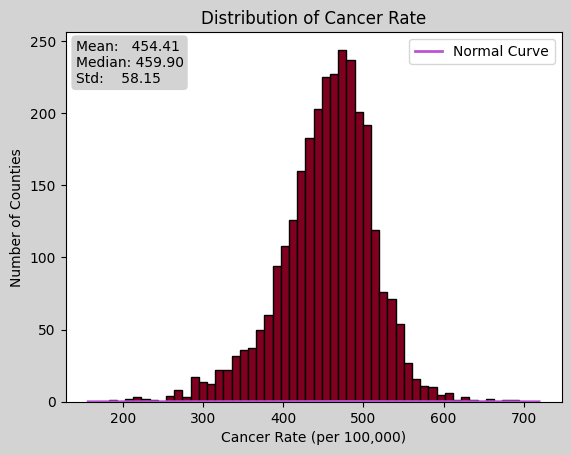


Scaling decision: Do not scale first attempt. Mean is .988 of median.
─────────────────────────────────────────────────────────────────────


In [ ]:
# ────────────────────────────────────────────────────────────────────────── <<<
# >>> CODE CELL 5.0: JUSTIFY SCALING DECISION                                <<<
# ────────────────────────────────────────────────────────────────────────── <<<
from scipy.stats import norm

dist_check = county_feature_matrix['cancer_rate']
mean = dist_check.mean()
median = dist_check.median()
std = dist_check.std()

print(f"Mean:   {mean:.2f}")
print(f"Median: {median:.2f}")
print(f"Std:    {std:.2f}")

fig, ax = plt.subplots(facecolor='lightgray')
ax.hist(dist_check, bins=50, color='#800020', edgecolor='black')


# Normal distribution curve
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 500)
p = norm.pdf(x, mean, std)
ax.plot(x, p * len(data) * (xmax - xmin) / 50, color='mediumorchid', linewidth=2, label='Normal Curve')

# Add legend
ax.legend()

# Annotate stats in top-left corner
stats_text = f"Mean:   {mean:.2f}\nMedian: {median:.2f}\nStd:    {std:.2f}"
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(facecolor='lightgray', edgecolor='none', boxstyle='round'))

# Label and title
ax.set_title('Distribution of Cancer Rate')
ax.set_xlabel('Cancer Rate (per 100,000)')
ax.set_ylabel('Number of Counties')
plt.show()
print()
print('Scaling decision: Do not scale first attempt. Mean is .988 of median.')
print('─────────────────────────────────────────────────────────────────────')

In [ ]:
# ────────────────────────────────────────────────────────────────────────── <<<
# >>> CODE CELL 5.2.1: ASSIGN COUNTY NODE TARGET LABELS                      <<<
# ────────────────────────────────────────────────────────────────────────── <<<
data['county'].y = torch.tensor(
    county_feature_matrix['cancer_rate'].values,
    dtype=torch.float32
)
print("Label shape:", data['county'].y.shape)

# ────────────────────────────────────────────────────────────────────────── <<<
# >>> CODE CELL 5.2.2: DEFINE MASKING                                        <<<
# ────────────────────────────────────────────────────────────────────────── <<<
num_county_nodes = data['county'].num_nodes
indices = np.arange(num_county_nodes)

train_idx, val_idx = train_test_split(indices, test_size=0.2,
                                      random_state=jenny)

# >>> Make the Masks <<<
train_mask = torch.zeros(num_county_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_county_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True

# >>> Assign to graph <<<
data['county'].train_mask = train_mask
data['county'].val_mask = val_mask

# ────────────────────────────────────────────────────────────────────────── <<<
# >>> CODE CELL 5.2.2: VALIDATION                                            <<<
# ────────────────────────────────────────────────────────────────────────── <<<
print("Total county nodes:", data['county'].num_nodes)
print("Train nodes:", data['county'].train_mask.sum().item())
print("Val nodes:", data['county'].val_mask.sum().item())
overlap = data['county'].train_mask & data['county'].val_mask
print("Train/Val Overlap:", overlap.sum().item())  # should be 0
train_y = data['county'].y[data['county'].train_mask]
val_y = data['county'].y[data['county'].val_mask]

print("Train mean:", train_y.mean().item())
print("Val mean:", val_y.mean().item())

Label shape: torch.Size([2930])
Total county nodes: 2930
Train nodes: 2344
Val nodes: 586
Train/Val Overlap: 0
Train mean: 454.3659362792969
Val mean: 454.57391357421875


```
# ────────────────────────────────────────────────────────────────────────── <<<
# >>> CODE CELL 6.0 HeteroGraphModel Class                                   <<<
# ────────────────────────────────────────────────────────────────────────── <<<
```

In [ ]:
# ────────────────────────────────────────────────────────────────────────── <<<
# >>> CODE CELL 6.1 HeteroGraphModel Class                                   <<<
# ────────────────────────────────────────────────────────────────────────── <<<
class HeteroGraphModel(nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        self.convs = nn.ModuleList([
            HeteroConv({
                ('superfund', 'located_in', 'county'): SAGEConv((-1, -1), hidden_channels),
                ('county', 'has_site', 'superfund'): SAGEConv((-1, -1), hidden_channels),
            }, aggr='mean'),
            HeteroConv({
                ('superfund', 'located_in', 'county'): SAGEConv((-1, -1), hidden_channels),
                ('county', 'has_site', 'superfund'): SAGEConv((-1, -1), hidden_channels),
            }, aggr='mean'),
            HeteroConv({
                ('superfund', 'located_in', 'county'): SAGEConv((-1, -1), hidden_channels),
                ('county', 'has_site', 'superfund'): SAGEConv((-1, -1), hidden_channels),
            }, aggr='mean'),
        ])
        self.lin = nn.Linear(hidden_channels, 1)

    def forward(self, x_dict, edge_index_dict):
        for i, conv in enumerate(self.convs):
            x_dict = conv(x_dict, edge_index_dict)
            if x_dict['county'] is None:
                raise RuntimeError(f"'county' became None after conv layer {i}")
            x_dict['county'] = F.relu(x_dict['county'])

        return self.lin(x_dict['county']).squeeze()

In [ ]:
# ────────────────────────────────────────────────────────────────────────── <<<
# >>> CODE CELL 6.2 TRAINING AND EVALUATION                                  <<<
# ────────────────────────────────────────────────────────────────────────── <<<

# >>> Inspect hetero graph and structure <<<
print("=== HeteroData Metadata ===")
print("Node types:", data.node_types)
print("Edge types:", data.edge_types)
print()

print("=== Edge Index Shapes ===")
for etype in data.edge_types:
    print(f"{etype}: {data[etype].edge_index.shape}")
print()

print("=== Node Feature Shapes ===")
for ntype in data.node_types:
    print(f"{ntype}: {data[ntype].x.shape}")
print()

print("=== Node Y Shape (if exists) ===")
if 'y' in data['county']:
    print("county.y:", data['county'].y.shape)

# >>> Instantiates model with 32 hidden channels <<<
model = HeteroGraphModel(hidden_channels=32)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()
print("Node features present:")
for node_type in data.node_types:
    x = data[node_type].x if 'x' in data[node_type] else None
    print(f"{node_type}: {None if x is None else x.shape}")

=== HeteroData Metadata ===
Node types: ['superfund', 'county']
Edge types: [('superfund', 'located_in', 'county'), ('county', 'has_site', 'superfund')]

=== Edge Index Shapes ===
('superfund', 'located_in', 'county'): torch.Size([2, 1505])
('county', 'has_site', 'superfund'): torch.Size([2, 1505])

=== Node Feature Shapes ===
superfund: torch.Size([1606, 739])
county: torch.Size([2930, 8])

=== Node Y Shape (if exists) ===
county.y: torch.Size([2930])
Node features present:
superfund: torch.Size([1606, 739])
county: torch.Size([2930, 8])


```
# ───────────────────────────────────────────────────────────────────────
# CELL 7.0: TRAINING
# ───────────────────────────────────────────────────────────────────────
```

In [ ]:
# ───────────────────────────────────────────────────────────────────────
# CELL 7.0: TRAINING
# ───────────────────────────────────────────────────────────────────────
start_time = time.time()

# >>> Set epoch ranges - maintain consistency between single trial/optuna <<<
# >>> ─────────────────────────────────────────────────────────────────── <<<
epoch_number = range(1, 501)
trial_number = 1 # primarily for use in Optuna later - n number of x epochs.

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x_dict, data.edge_index_dict)
    loss = loss_fn(out[data['county'].train_mask], data['county'].y[data['county'].train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate():
    model.eval()
    with torch.no_grad():
        out = model(data.x_dict, data.edge_index_dict)
        preds = out[data['county'].val_mask].detach().cpu().numpy()
        targets = data['county'].y[data['county'].val_mask].detach().cpu().numpy()
        mse = mean_squared_error(targets, preds)
        rmse = np.sqrt(mse)
        r2 = r2_score(targets, preds)
    return mse, rmse, r2

# Run the training loop
# ───────────────────────────────────────────────────────────────────────
training_log = []
for epoch in epoch_number:
    loss = train()
    mse, rmse, r2 = evaluate()
    training_log.append({
        'EPOCH_': epoch,
        'train_MSE_': loss,
        'train_RMSE_': math.sqrt(loss),
        'validation_MSE_': mse,
        'validation_RMSE_': rmse,
        'worthless_R2_': r2
    })
    if epoch % 25 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Val MSE: {mse:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")

running_time = time.time() - start_time
training_df = pd.DataFrame(training_log)
training_df['execution_runtime'] = running_time

# ───────────────────────────────────────────────────────────────────────
# >>> CELL 7.1: Single Trial GNN Model Training Log                   <<<
# ───────────────────────────────────────────────────────────────────────
print("── SINGLE EPOCH RUNTIME ───────────────────────────────────")
print(f"Optuna Execution in seconds: [>> {running_time:.2f} <<]")
print()
print("── RMSE EVAL ──────────────────────────────────────────────")
display(training_df.sort_values(by='validation_RMSE_', ascending=True).head(3))
print()
print("── R2 EVAL ────────────────────────────────────────────────")
display(training_df.sort_values(by='worthless_R2_', ascending=False).head(3))

single_trial_fname = 'April20_test_50epoch'
single_trial_ftype = '.csv'
single_trial_filename = single_trial_fname + single_trial_ftype
training_df.to_csv(single_trial_filename, index=None)

#time.sleep(2)
#files.download(single_trial_filename)

Epoch 001 | Loss: 179836.1562 | Val MSE: 238791.3125 | RMSE: 488.6628 | R2: -69.1252
Epoch 025 | Loss: 134525.8750 | Val MSE: 134871.7344 | RMSE: 367.2489 | R2: -38.6074
Epoch 050 | Loss: 130907.9062 | Val MSE: 132063.3438 | RMSE: 363.4052 | R2: -37.7827
Epoch 075 | Loss: 120488.1797 | Val MSE: 121727.3438 | RMSE: 348.8945 | R2: -34.7473
Epoch 100 | Loss: 46640.4531 | Val MSE: 40586.9883 | RMSE: 201.4621 | R2: -10.9191
Epoch 125 | Loss: 6696.5376 | Val MSE: 7146.6118 | RMSE: 84.5376 | R2: -1.0987
Epoch 150 | Loss: 8706.7539 | Val MSE: 8897.2051 | RMSE: 94.3250 | R2: -1.6128
Epoch 175 | Loss: 3681.1660 | Val MSE: 3427.3184 | RMSE: 58.5433 | R2: -0.0065
Epoch 200 | Loss: 3134.9045 | Val MSE: 3083.4065 | RMSE: 55.5284 | R2: 0.0945
Epoch 225 | Loss: 3462.8704 | Val MSE: 3165.3418 | RMSE: 56.2614 | R2: 0.0704
Epoch 250 | Loss: 3099.8164 | Val MSE: 2978.7812 | RMSE: 54.5782 | R2: 0.1252
Epoch 275 | Loss: 3300.9114 | Val MSE: 2982.5220 | RMSE: 54.6125 | R2: 0.1241
Epoch 300 | Loss: 2881.6267 

,EPOCH_,train_MSE_,train_RMSE_,validation_MSE_,validation_RMSE_,worthless_R2_,execution_runtime
472,473,2540.922852,50.407567,2680.488525,51.773435,0.212828,10.15284
473,474,2533.500488,50.333890,2686.570068,51.832134,0.211042,10.15284
474,475,2530.467773,50.303755,2689.026367,51.855823,0.210321,10.15284



── R2 EVAL ────────────────────────────────────────────────


,EPOCH_,train_MSE_,train_RMSE_,validation_MSE_,validation_RMSE_,worthless_R2_,execution_runtime
472,473,2540.922852,50.407567,2680.488525,51.773435,0.212828,10.15284
473,474,2533.500488,50.333890,2686.570068,51.832134,0.211042,10.15284
474,475,2530.467773,50.303755,2689.026367,51.855823,0.210321,10.15284


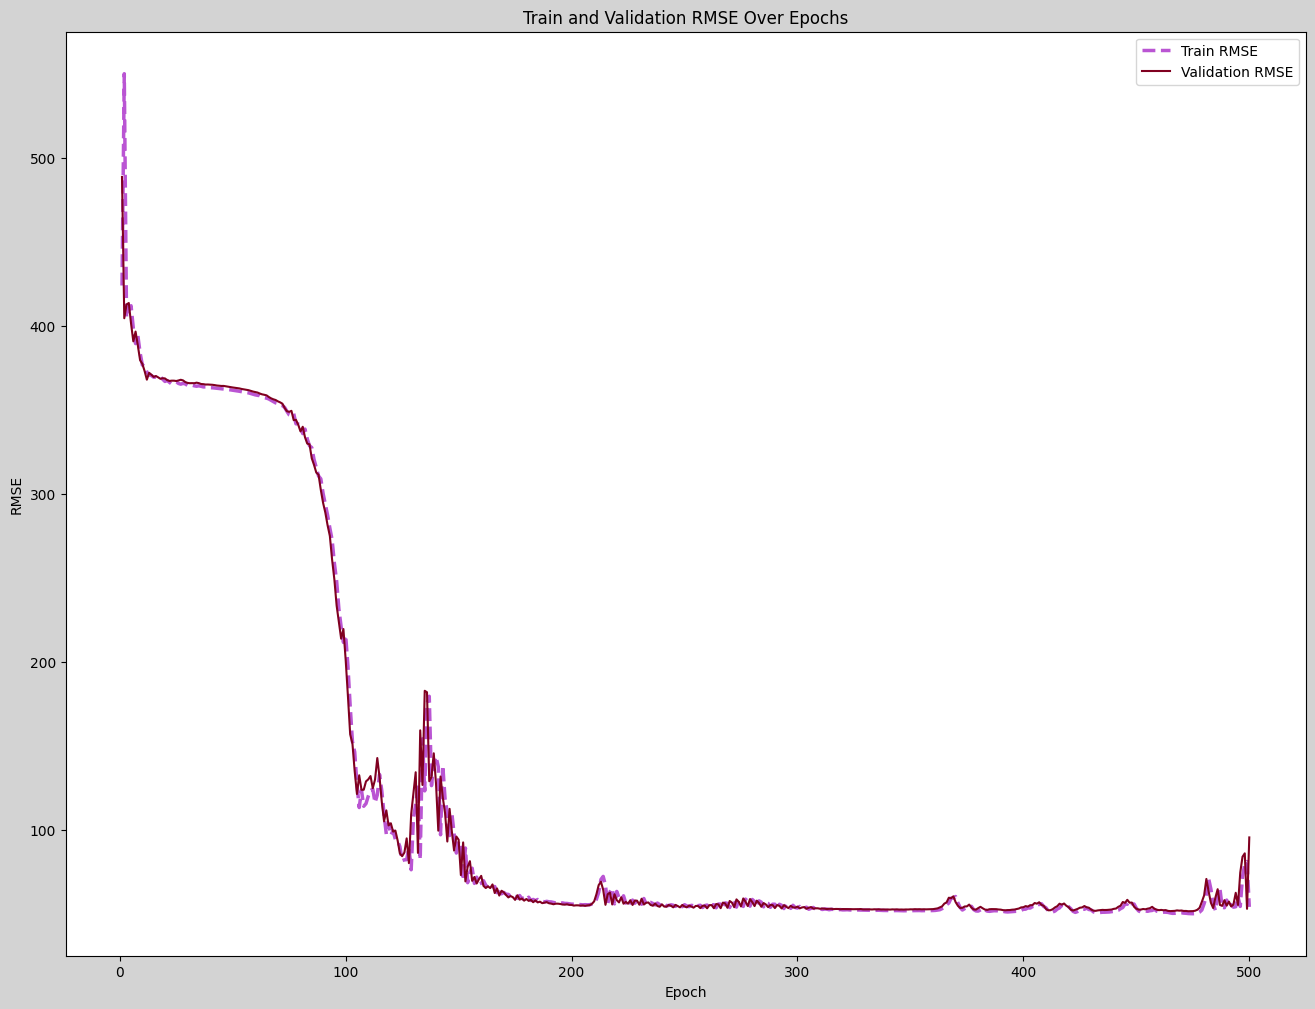

In [ ]:
# ────────────────────────────────────────────────────────────────────────── <<<
# >>> VALIDATION RMSE VISUALIZATION                                          <<<
# ────────────────────────────────────────────────────────────────────────── <<<
fig, ax = plt.subplots(figsize=(16,12), facecolor='lightgray')

# >>> train_RMSE_: medium orchid <<<
ax.plot(training_df['EPOCH_'], training_df['train_RMSE_'],
        color='mediumorchid', linestyle='--', linewidth=2.5,
        label='Train RMSE')

# >>> validation_RMSE_: burgundy <<<
ax.plot(training_df['EPOCH_'], training_df['validation_RMSE_'],
        color='#800020', label='Validation RMSE')

ax.set_title('Train and Validation RMSE Over Epochs')
ax.set_xlabel('Epoch')
ax.set_ylabel('RMSE')
ax.legend()
plt.show()

In [ ]:
# ────────────────────────────────────────────────────────────────────────── <<<
# >>> CODE CELL 999: Scratch                                                 <<<
# ────────────────────────────────────────────────────────────────────────── <<<
print('county_feature_matrix columns: ')
print(county_feature_matrix.columns)
print()
print('-------------------------------')
print('county_node_id_map columns: ')
print(county_node_id_map.columns)
print()
print('-------------------------------')
print('superfund_feature_matrix columns: ')
print(superfund_feature_matrix.columns)
print()
print('-------------------------------')
print('superfund_node_id_map columns: ')
print(superfund_node_id_map.columns)
print()
print('-------------------------------')
print()
print(len(county_feature_matrix))
print('-------------------------------')
print(county_feature_matrix)

county_feature_matrix columns: 
Index(['cancer_rate', 'avg_annual_count', 'five_year_trend', 'rural_rural',
       'rural_urban', 'trend_', 'trend_falling', 'trend_rising',
       'trend_stable'],
      dtype='object')

-------------------------------
county_node_id_map columns: 
Index(['row_index', 'fips'], dtype='object')

-------------------------------
superfund_feature_matrix columns: 
Index(['lat', 'lon', 'fed_facility', 'native_land', 'hazard_rank_score',
       'final_list_days', 'proposed_days', 'proposal_gulf', 'is_finalized',
       'is_deleted',
       ...
       '99-35-4', '99-65-0', '99-87-6', '99-99-0', '993-13-5', 'UNASSIGNED',
       'cas_sum', 'npl_current', 'npl_deleted', 'npl_proposed'],
      dtype='object', length=739)

-------------------------------
superfund_node_id_map columns: 
Index(['row_index', 'site_id', 'fips'], dtype='object')

-------------------------------

2930
-------------------------------
      cancer_rate  avg_annual_count  five_year_trend  rur